In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data - make sure the path points to your CSV
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True)

# 1. Basic Cleaning
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Date Conversion (Financial news uses UTC-4 usually)
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['date'])

# 3. Simple Headline Length Stat
df['headline_len'] = df['headline'].apply(len)

print(f"Dataset Stats: {df.shape[0]} rows")
print(f"Top Publishers:\n{df['publisher'].value_counts().head(5)}")

Dataset Stats: 55987 rows
Top Publishers:
publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Name: count, dtype: int64


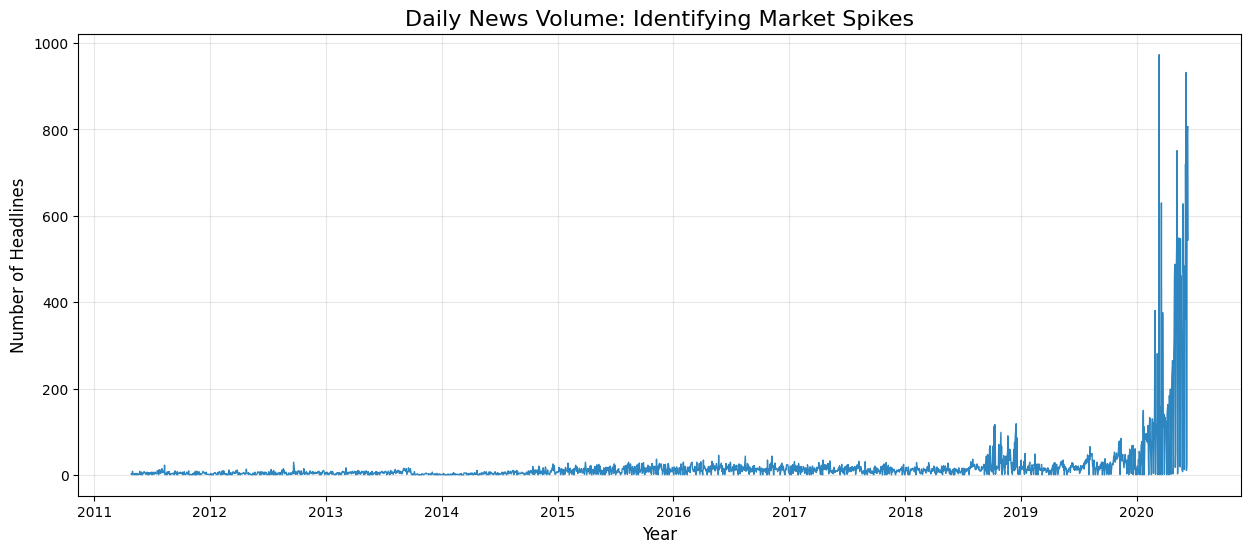

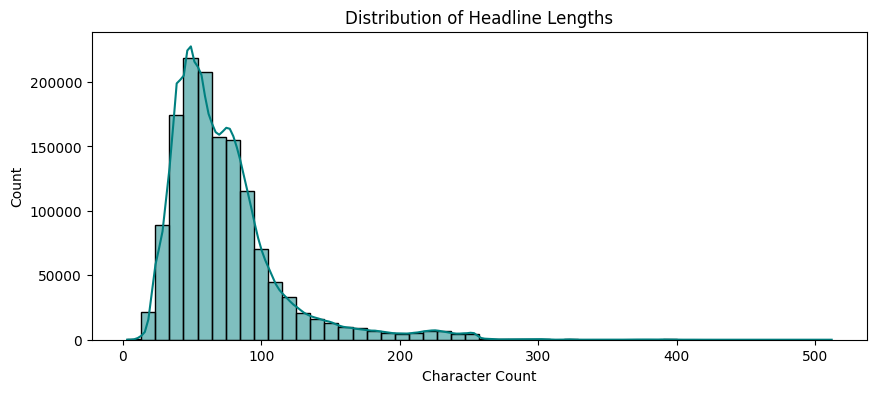

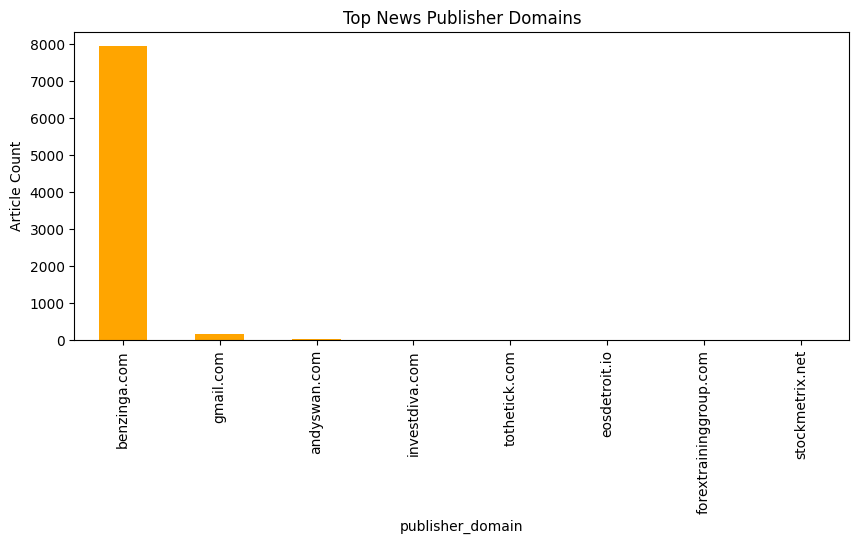

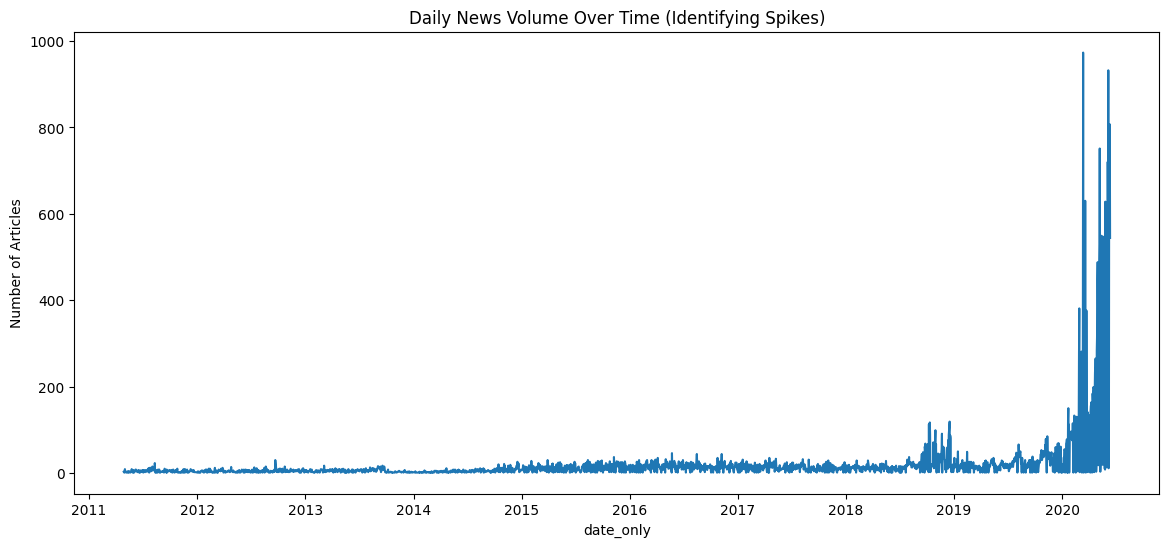

In [14]:
# Grouping by day to see the volume of news over time
daily_counts = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15, 6))
daily_counts.plot(kind='line', color='#2E86C1', lw=1)

plt.title('Daily News Volume: Identifying Market Spikes', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Headlines', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 1. Headline Length Analysis
news_df['headline_len'] = news_df['headline'].apply(len)
plt.figure(figsize=(10, 4))
sns.histplot(news_df['headline_len'], bins=50, kde=True, color='teal')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Character Count')
plt.show()

# 2. Publisher Domain Extraction (The 'name news_df' fix)
# This looks for emails and grabs the domain (e.g., reuters.com)
news_df['publisher_domain'] = news_df['publisher'].str.extract(r'@([\w\.-]+)')
top_domains = news_df['publisher_domain'].value_counts().head(10)

if not top_domains.empty:
    plt.figure(figsize=(10, 4))
    top_domains.plot(kind='bar', color='orange')
    plt.title('Top News Publisher Domains')
    plt.ylabel('Article Count')
    plt.show()
else:
    print("No email-based publishers found. Top standard publishers:")
    print(news_df['publisher'].value_counts().head(10))

# 3. Publication Frequency (Time Series)
news_df['date_only'] = news_df['date'].dt.date
plt.figure(figsize=(14, 6))
news_df.groupby('date_only').size().plot()
plt.title('Daily News Volume Over Time (Identifying Spikes)')
plt.ylabel('Number of Articles')
plt.show()

C:\Users\mekli\AppData\Local\Temp\ipykernel_22252\2408069239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')


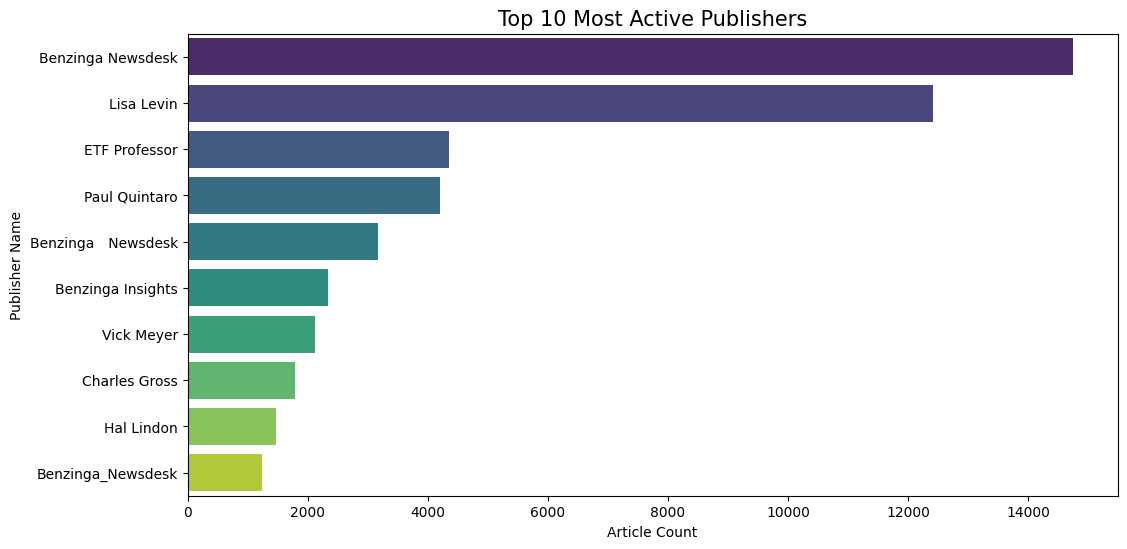

In [16]:
# Get the top 10 most active publishers
top_publishers = df['publisher'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')
plt.title('Top 10 Most Active Publishers', fontsize=15)
plt.xlabel('Article Count')
plt.ylabel('Publisher Name')
plt.show()


52: 8453
companies: 4778
eps: 5531
hit: 5902
market: 5482
price: 5046
shares: 8393
stocks: 12794
trading: 6575
week: 9029


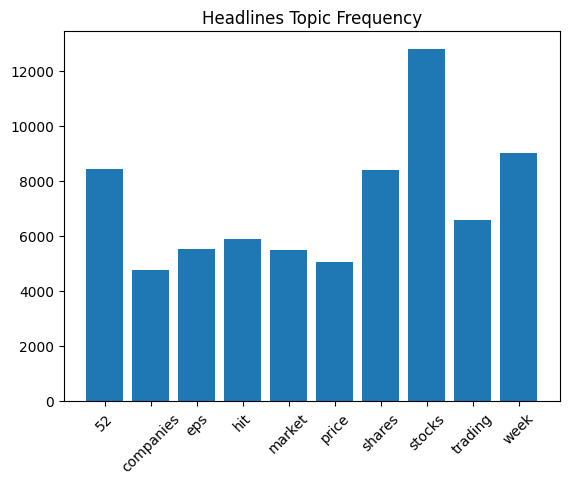

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Extract keywords
vec = CountVectorizer(stop_words='english', max_features=10)
counts = vec.fit_transform(df['headline'])

# Get words and their frequency
words = vec.get_feature_names_out()
freqs = counts.toarray().sum(axis=0)

# Print them out so I can see what the market is talking about
for word, freq in zip(words, freqs):
    print(f"{word}: {freq}")

# Quick Plot
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Headlines Topic Frequency")
plt.show()

publisher_domain
benzinga.com      7937
gmail.com          139
andyswan.com         5
investdiva.com       2
tothetick.com        2
Name: count, dtype: int64


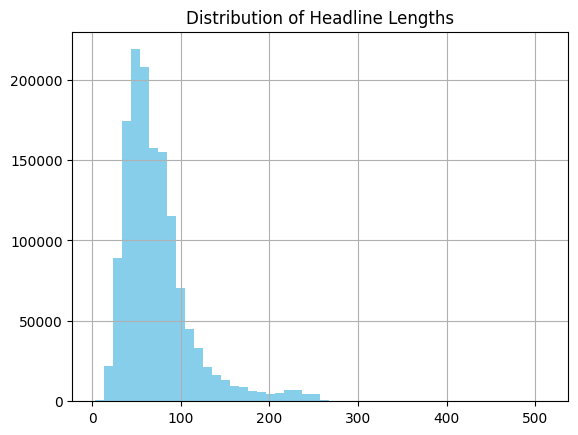

In [18]:
# Quick check for Publisher Domains
news_df['publisher_domain'] = news_df['publisher'].str.extract(r'@([\w\.-]+)')
print(news_df['publisher_domain'].value_counts().head())

# Quick Histogram of Headline Lengths
news_df['headline_len'] = news_df['headline'].apply(len)
news_df['headline_len'].hist(bins=50, color='skyblue')
plt.title('Distribution of Headline Lengths')
plt.show()

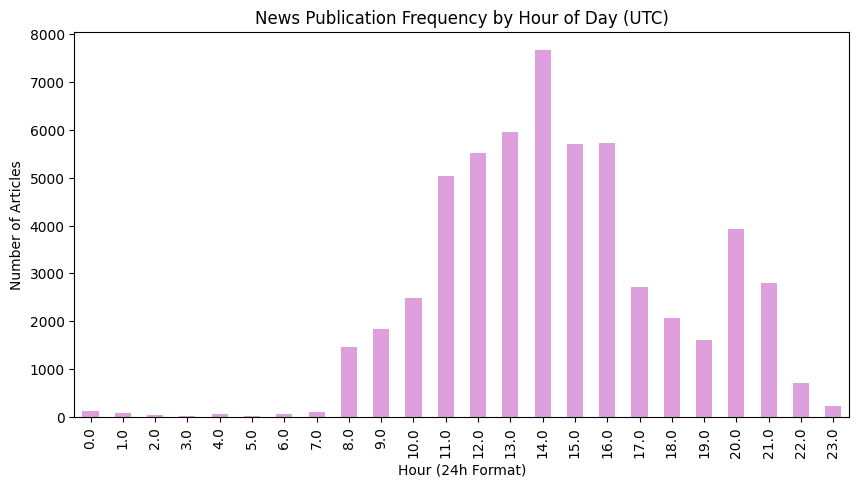

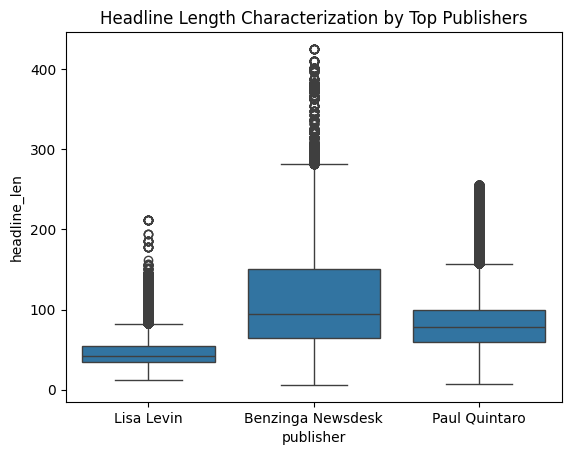

In [19]:
# 1. Hourly Distribution (Required by: "Analyze publishing times")
news_df['hour'] = pd.to_datetime(news_df['date'], utc=True).dt.hour
plt.figure(figsize=(10, 5))
news_df['hour'].value_counts().sort_index().plot(kind='bar', color='plum')
plt.title('News Publication Frequency by Hour of Day (UTC)')
plt.xlabel('Hour (24h Format)')
plt.ylabel('Number of Articles')
plt.show()

# 2. Publisher Type Characterization
# Let's see if the top publisher (Benzinga) has a different length style than others
top_3_publishers = news_df['publisher'].value_counts().head(3).index
sns.boxplot(data=news_df[news_df['publisher'].isin(top_3_publishers)], 
            x='publisher', y='headline_len')
plt.title('Headline Length Characterization by Top Publishers')
plt.show()